In [1]:
import copy
import glob
import json
import os
import random
import re
from copy import deepcopy as dc
from os.path import join as opj

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, Normalize
from scipy.stats import spearmanr

from cloth_fmri.config.config import CONFIG
from cloth_fmri.models.model_predictions import (woven_stiff_pred, cnn_stiff_pred, 
                                                 vjepa2_stiff_pred, vivit_stiff_pred, videomae_stiff_pred)
from cloth_fmri.utils.rdm import (
    build_model_rdm_from_stiffness_predictions,
    build_rdm,
    upper_to_square_rdm,
)
from cloth_fmri.utils.stats import (
    bootstrap_sample,
    get_mode_value,
    bootstrap_cor,
    calc_p,
)

from cloth_fmri.utils.plot import (
    plot_bootstrap_violin,
    plot_model_rdm_matrix,
    plot_rdm_heatmap_from_upper,
    plot_two_distribution_violin,
)


random.seed(9)

models = ["woven", "vjepa2", "videomae", "vivit", "cnn"]
# models = ["woven", "vjepa2", "videomae", "cnn"]
c_ls = ["0.1", "1.0", "10.0", "100.0"]
SUBJECT_LIST = CONFIG["subjects"]
SCENES = CONFIG['scenes']
ROIS = ["tower", "v1"]

human_rdm_root_dir = opj(CONFIG["output_root"], "analysis", "fig4")
bootn = 10000

/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/outdated/utils.py:18: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs


In [2]:
# ----------------------------------------------------
# Build model RDMs
# ----------------------------------------------------
model_pred_dict = {
    "woven": woven_stiff_pred,
    "vjepa2": vjepa2_stiff_pred,
    "videomae": videomae_stiff_pred,
    "vivit": vivit_stiff_pred,
    "cnn": cnn_stiff_pred,
}

models_rdm = {}

for model in models:
    rdm_vec, rdm_full = build_model_rdm_from_stiffness_predictions(model_pred_dict[model], SCENES)
    models_rdm[model] = rdm_vec


In [3]:
# ----------------------------------------------------
# Containers
# ----------------------------------------------------
best_r = {roi: {model: [] for model in models} for roi in ROIS}
best_bootstrap_r = {roi: {model: [] for model in models} for roi in ROIS}

best_human_rdm = {}
best_subject_rdms = {}
best_split_half = {}


# ----------------------------------------------------
# Search best human RDM and compute model correlations
# ----------------------------------------------------
for roi in ROIS:
    best_split_half_cor = -1.0
    best_split_half_p = None
    best_bootstrap_correlation = None
    best_rdm_avg_all_subs = None
    best_rdm_all_subs = None

    best_mean_r = {model: None for model in models}
    best_bootstrap_p = {model: None for model in models}

    for c in c_ls:
        cur_human_rdm_dir = opj(human_rdm_root_dir, roi, f"C={c}")
        matching_files = glob.glob(f"{cur_human_rdm_dir}/*.json*")

        if len(matching_files) == 0:
            continue

        flag = True

        for file in matching_files:
            with open(file, "r") as f:
                data = json.load(f)

            if flag:
                flag = False
                all_data = copy.deepcopy(data)

                for key_sub in all_data.keys():
                    for key_scene in all_data[key_sub].keys():
                        all_data[key_sub][key_scene] = [all_data[key_sub][key_scene]]
            else:
                for key_sub in all_data.keys():
                    for key_scene in all_data[key_sub].keys():
                        all_data[key_sub][key_scene].append(data[key_sub][key_scene])

        # ----------------------------------------------------
        # Average over iterations using mode
        # ----------------------------------------------------
        all_data_mean = copy.deepcopy(all_data)

        for key_sub in all_data.keys():
            for key_scene in all_data[key_sub].keys():
                all_data_mean[key_sub][key_scene] = get_mode_value(
                    all_data[key_sub][key_scene]
                )

        # ----------------------------------------------------
        # Subject-level RDM and model correlations
        # ----------------------------------------------------
        rdm_all_subs = {}
        r_model = {
            model: {}
            for model in models
        }

        for sub in SUBJECT_LIST:
            if sub in all_data_mean:
                rdm_all_subs[sub] = build_rdm(all_data_mean[sub], SCENES, plot=False)
                for model in models:
                    r_model[model][sub] = spearmanr(models_rdm[model], rdm_all_subs[sub])[0]

        rdm_avg_all_subs = np.mean(np.array(list(rdm_all_subs.values())), axis=0)
        mean_r = {model: round(np.mean(list(r_model[model].values())), 3) for model in models}

        # ----------------------------------------------------
        # Bootstrap model correlations
        # ----------------------------------------------------
        bootstrap_r = {}

        for model in models:
            bootstrap_r[model] = [
                np.mean(bootstrap_sample(list(r_model[model].values())))
                for _ in range(bootn)
            ]

        bootstrap_p = {model: calc_p(bootstrap_r[model]) for model in models}
        # ----------------------------------------------------
        # Split-half reliability
        # ----------------------------------------------------
        my_split_half_data = np.array(list(rdm_all_subs.values()))

        split_half_cor, split_half_p, bootstrap_correlations = bootstrap_cor(
            my_split_half_data,
            seed=0,
        )

        if split_half_cor >= best_split_half_cor:
            best_split_half_cor = split_half_cor
            best_split_half_p = split_half_p

            best_bootstrap_correlation = dc(bootstrap_correlations)
            best_rdm_avg_all_subs = dc(rdm_avg_all_subs)
            best_rdm_all_subs = dc(rdm_all_subs)

            for model in models:
                best_mean_r[model] = mean_r[model]
                best_bootstrap_p[model] = bootstrap_p[model]

                best_r[roi][model] = list(r_model[model].values())
                best_bootstrap_r[roi][model] = dc(bootstrap_r[model])

    # ----------------------------------------------------
    # Save best result
    # ----------------------------------------------------
    best_human_rdm[roi] = dc(best_rdm_avg_all_subs)
    best_subject_rdms[roi] = dc(best_rdm_all_subs)

    best_split_half[roi] = {
        "r": best_split_half_cor,
        "p": best_split_half_p,
        "bootstrap": dc(best_bootstrap_correlation),
    }

In [4]:
# In[4]: Layer-wise correlations + Model x ROI interaction test

video_model_dirs = {
    "vjepa2": "vjepa2_hf_ridge_mean_1.0_ntrain=7075",
    "videomae": "videomae_ridge_mean_1.0_ntrain=7075",
    "vivit": "vivit_ridge_cls_1.0_ntrain=7075",
}

woven_rdm = models_rdm["woven"]
dnn_rdm = models_rdm["cnn"]

layer_results = []

for video_model, model_dir_name in video_model_dirs.items():

    pred_dict_dir = opj(
        CONFIG["output_root"],
        "analysis",
        "model_predictions_all_layers",
        model_dir_name,
    )

    pred_dict_files = sorted(
        glob.glob(opj(pred_dict_dir, "pred_dict_layer_index=*_layer_number=*.npy")),
        key=lambda x: int(re.search(r"layer_index=(\d+)", x).group(1)),
    )

    if len(pred_dict_files) == 0:
        print(f"No layer pred_dict files found for {video_model}")
        continue

    print("\n" + "="*100)
    print(f"MODEL: {video_model}")
    print("="*100)

    for pred_dict_path in pred_dict_files:

        layer_index = int(re.search(r"layer_index=(\d+)", pred_dict_path).group(1))
        layer_number = int(re.search(r"layer_number=(\d+)", pred_dict_path).group(1))

        layer_pred_dict = np.load(pred_dict_path, allow_pickle=True).item()

        layer_rdm, _ = build_model_rdm_from_stiffness_predictions(
            layer_pred_dict,
            SCENES,
        )

        woven_r = spearmanr(layer_rdm, woven_rdm)[0]
        dnn_r = spearmanr(layer_rdm, dnn_rdm)[0]

        print(
            f"\nLayer {layer_number}: "
            f"WOVEN={woven_r:.3f}, DNN={dnn_r:.3f}"
        )

        result_row = {
            "model": video_model,
            "layer_index": layer_index,
            "layer_number": layer_number,
            "woven_spearman": woven_r,
            "dnn_spearman": dnn_r,
            "pred_dict_path": pred_dict_path,
        }


        # -----------------------------
        # Neural correlations
        # -----------------------------

        for roi in ROIS:

            neural_r_by_subject = [
                spearmanr(layer_rdm, subject_rdm)[0]
                for subject_rdm in best_subject_rdms[roi].values()
            ]

            neural_r = np.mean(neural_r_by_subject)

            neural_bootstrap_r = [
                np.mean(bootstrap_sample(neural_r_by_subject))
                for _ in range(bootn)
            ]

            result_row[f"{roi}_neural_spearman"] = neural_r
            result_row[f"{roi}_neural_p"] = calc_p(neural_bootstrap_r)

            result_row[f"{roi}_bootstrap_mean"] = np.mean(neural_bootstrap_r)
            result_row[f"{roi}_bootstrap_ci_low"] = np.percentile(neural_bootstrap_r, 2.5)
            result_row[f"{roi}_bootstrap_ci_high"] = np.percentile(neural_bootstrap_r, 97.5)

            print(
                f"    {roi}: r={neural_r:.3f}, "
                f"p={result_row[f'{roi}_neural_p']:.3f}"
            )


        # -----------------------------
        # Model x ROI interaction data
        # -----------------------------

        interaction_rows = []

        for sub in SUBJECT_LIST:

            if sub not in best_subject_rdms["tower"] or sub not in best_subject_rdms["v1"]:
                continue

            tower_rdm = best_subject_rdms["tower"][sub]
            v1_rdm = best_subject_rdms["v1"][sub]

            interaction_rows += [
                {
                    "subject": sub,
                    "Model": "Layer",
                    "ROI": "Physics",
                    "r": spearmanr(layer_rdm, tower_rdm)[0],
                },
                {
                    "subject": sub,
                    "Model": "Layer",
                    "ROI": "V1",
                    "r": spearmanr(layer_rdm, v1_rdm)[0],
                },
                {
                    "subject": sub,
                    "Model": "DNN",
                    "ROI": "Physics",
                    "r": spearmanr(dnn_rdm, tower_rdm)[0],
                },
                {
                    "subject": sub,
                    "Model": "DNN",
                    "ROI": "V1",
                    "r": spearmanr(dnn_rdm, v1_rdm)[0],
                },
            ]

        interaction_df = pd.DataFrame(interaction_rows)

        interaction_df["z"] = np.arctanh(interaction_df["r"])
        # -----------------------------
        # Model x ROI interaction ANOVA
        # -----------------------------

        interaction_anova = pg.rm_anova(
            data=interaction_df,
            dv="z",
            within=["Model", "ROI"],
            subject="subject",
            detailed=True,
        )

        interaction_F = interaction_anova.loc[
            interaction_anova["Source"] == "Model * ROI",
            "F"
        ].values[0]

        interaction_p = interaction_anova.loc[
            interaction_anova["Source"] == "Model * ROI",
            "p-unc"
        ].values[0]

        result_row["interaction_F"] = interaction_F
        result_row["interaction_p"] = interaction_p

        print(
            f"    Model x ROI interaction: "
            f"F={interaction_F:.3f}, "
            f"p={interaction_p:.4f}"
        )


        # -----------------------------
        # Plot interaction
        # -----------------------------

        summary = interaction_df.groupby(
            ["Model", "ROI"]
        )["z"].agg(
            ["mean", "sem"]
        ).reset_index()


#         ymin = (summary["mean"] - 2*summary["sem"]).min()
#         ymax = (summary["mean"] + 2*summary["sem"]).max()
#         margin = max((ymax-ymin)*0.3, 0.1)


#         plt.figure(figsize=(5,4))

#         sns.pointplot(
#             data=interaction_df,
#             x="Model",
#             y="z",
#             hue="ROI",
#             errorbar="se",
#             dodge=True,
#             markers=["o","s"],
#         )

#         plt.ylim(
#             ymin-margin,
#             ymax+margin,
#         )

#         plt.axhline(
#             0,
#             linestyle="--",
#             linewidth=1,
#         )

#         plt.title(
#             f"{video_model} layer {layer_number}\n"
#             f"Model × ROI interaction p={interaction_p:.4f}"
#         )

#         plt.ylabel(
#             "RSA correlation (Fisher z)"
#         )

#         plt.xlabel("")

#         plt.tight_layout()


        layer_results.append(
            result_row
        )


# ----------------------------------------------------
# Save results
# ----------------------------------------------------

layer_results_df = pd.DataFrame(
    layer_results
)


if not layer_results_df.empty:

    layer_results_df = (
        layer_results_df
        .sort_values(
            [
                "model",
                "layer_index",
            ]
        )
        .reset_index(drop=True)
    )


    layer_results_path = opj(
        CONFIG["output_root"],
        "analysis",
        "model_predictions_all_layers",
        "video_models_layer_interaction_results.csv",
    )


    layer_results_df.to_csv(
        layer_results_path,
        index=False,
    )


    print("\nSaved:")
    print(layer_results_path)


    print("\nSummary:")


    summary_cols = [
        "model",
        "layer_number",
        "tower_neural_spearman",
        "v1_neural_spearman",
        "woven_spearman",
        "dnn_spearman",
        "interaction_F",
        "interaction_p",
    ]


    print(
        layer_results_df[
            summary_cols
        ].to_csv(
            index=False,
            sep="\t",
            float_format="%.3f",
        )
    )


MODEL: vjepa2

Layer 1: WOVEN=0.543, DNN=0.429
    tower: r=0.125, p=0.093
    v1: r=0.053, p=0.560
    Model x ROI interaction: F=6.203, p=0.0204

Layer 2: WOVEN=-0.086, DNN=0.314
    tower: r=0.006, p=0.930
    v1: r=-0.002, p=0.944
    Model x ROI interaction: F=2.633, p=0.1183

Layer 3: WOVEN=0.200, DNN=-0.486
    tower: r=0.178, p=0.075
    v1: r=0.024, p=0.778
    Model x ROI interaction: F=3.970, p=0.0583

Layer 4: WOVEN=0.886, DNN=0.143
    tower: r=0.264, p=0.006
    v1: r=0.089, p=0.274
    Model x ROI interaction: F=8.006, p=0.0095

Layer 5: WOVEN=-0.200, DNN=-0.200
    tower: r=0.019, p=0.816
    v1: r=-0.062, p=0.498
    Model x ROI interaction: F=3.402, p=0.0780

Layer 6: WOVEN=0.314, DNN=0.657
    tower: r=0.081, p=0.299
    v1: r=0.105, p=0.178
    Model x ROI interaction: F=4.677, p=0.0412

Layer 7: WOVEN=0.829, DNN=0.429
    tower: r=0.215, p=0.007
    v1: r=0.097, p=0.248
    Model x ROI interaction: F=nan, p=nan

Layer 8: WOVEN=0.314, DNN=0.657


/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pandas/core/arraylike.py:358: RuntimeWarning: divide by zero encountered in arctanh
  result = getattr(ufunc, method)(*inputs, **kwargs)
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:718: RuntimeWarning: invalid value encountered in double_scalars
  ss_ab = ss_ab_er - ss_a - ss_b
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:720: RuntimeWarning: invalid value encountered in double_scalars
  ss_as = ss_as_er - ss_s - ss_a
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:722: RuntimeWarning: invalid value encountered in double_scalars
  ss_bs = ss_bs_er - ss_s - ss_b
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:723: RuntimeWarning: invalid value encount

    tower: r=0.081, p=0.304
    v1: r=0.105, p=0.175
    Model x ROI interaction: F=4.677, p=0.0412

Layer 9: WOVEN=-0.143, DNN=-0.371
    tower: r=-0.009, p=0.905
    v1: r=-0.073, p=0.436
    Model x ROI interaction: F=3.310, p=0.0819

Layer 10: WOVEN=0.257, DNN=-0.771
    tower: r=0.091, p=0.329
    v1: r=-0.212, p=0.014
    Model x ROI interaction: F=6.087, p=0.0215

Layer 11: WOVEN=0.829, DNN=0.429
    tower: r=0.215, p=0.008
    v1: r=0.097, p=0.246
    Model x ROI interaction: F=nan, p=nan

Layer 12: WOVEN=-0.486, DNN=-0.086


/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pandas/core/arraylike.py:358: RuntimeWarning: divide by zero encountered in arctanh
  result = getattr(ufunc, method)(*inputs, **kwargs)
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:718: RuntimeWarning: invalid value encountered in double_scalars
  ss_ab = ss_ab_er - ss_a - ss_b
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:720: RuntimeWarning: invalid value encountered in double_scalars
  ss_as = ss_as_er - ss_s - ss_a
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:722: RuntimeWarning: invalid value encountered in double_scalars
  ss_bs = ss_bs_er - ss_s - ss_b
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:723: RuntimeWarning: invalid value encount

    tower: r=-0.054, p=0.511
    v1: r=-0.060, p=0.480
    Model x ROI interaction: F=1.285, p=0.2687

Layer 13: WOVEN=-0.486, DNN=-0.371
    tower: r=-0.023, p=0.798
    v1: r=-0.038, p=0.675
    Model x ROI interaction: F=1.388, p=0.2508

Layer 14: WOVEN=-0.371, DNN=-0.086
    tower: r=-0.022, p=0.805
    v1: r=-0.006, p=0.970
    Model x ROI interaction: F=2.307, p=0.1425

Layer 15: WOVEN=0.771, DNN=-0.086
    tower: r=0.247, p=0.012
    v1: r=0.008, p=0.922
    Model x ROI interaction: F=8.752, p=0.0070

Layer 16: WOVEN=-0.029, DNN=0.143
    tower: r=0.024, p=0.741
    v1: r=-0.029, p=0.710
    Model x ROI interaction: F=2.435, p=0.1323

Layer 17: WOVEN=-0.200, DNN=-0.200
    tower: r=0.019, p=0.801
    v1: r=-0.062, p=0.502
    Model x ROI interaction: F=3.402, p=0.0780

Layer 18: WOVEN=0.200, DNN=0.429
    tower: r=0.064, p=0.394
    v1: r=0.023, p=0.769
    Model x ROI interaction: F=4.267, p=0.0503

Layer 19: WOVEN=-0.543, DNN=-0.029
    tower: r=-0.136, p=0.072
    v1: r=-0.14

In [5]:
# # In[5]:


# # ----------------------------------------------------
# # Plot RDM-model correlations: one figure per ROI
# # ----------------------------------------------------

# roi_name_map = {
#     "tower": "Physics ROI",
#     "v1": "V1",
# }


# for roi in ['v1']: #ROIS:

#     plot_rows = []

#     for model in models:
#         for r in best_bootstrap_r[roi][model]:
#             plot_rows.append({
#                 "Model": model,
#                 "Spearman r": r,
#             })

#     plot_df = pd.DataFrame(plot_rows)

#     fig, ax = plt.subplots(figsize=(10, 6))

#     sns.violinplot(
#         data=plot_df,
#         x="Model",
#         y="Spearman r",
#         order=models,
#         inner=None,
#         cut=0,
#         ax=ax,
#     )

#     ax.axhline(
#         y=0.0,
#         color="black",
#         linestyle="--",
#         linewidth=1,
#     )


#     ax.set_title(
#         f"{roi_name_map[roi]}: Correlations between neural similarity matrices and models",
#         fontsize=14,
#     )
#     ax.set_xlabel("Model")
#     ax.set_ylabel("Correlation b/w model and neural stiffness similarity matrices")

#     plt.tight_layout()
#     plt.show()

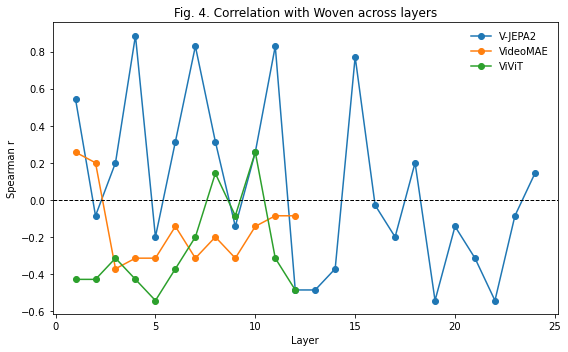

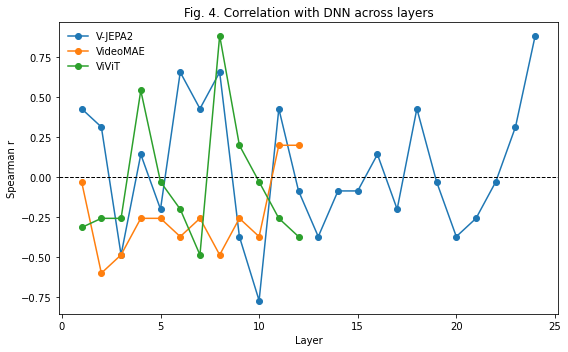

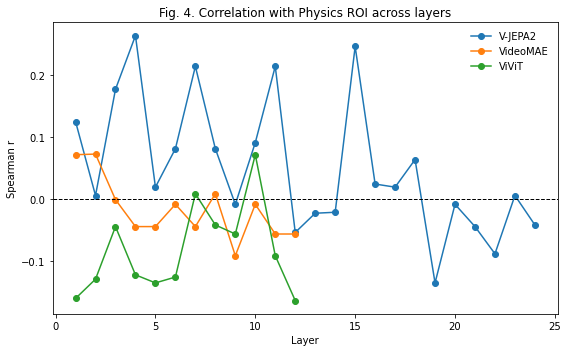

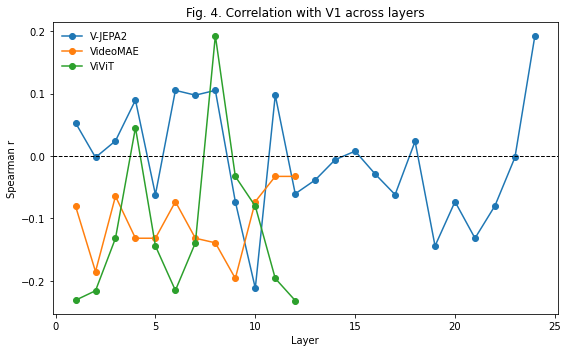

In [6]:
# In[6]: Line plots across layers

if not layer_results_df.empty:

    plot_model_order = ["vjepa2", "videomae", "vivit"]

    label_map = {
        "vjepa2": "V-JEPA2",
        "videomae": "VideoMAE",
        "vivit": "ViViT",
    }

    # ----------------------------------------------------
    # 1. Correlation with Woven across layers
    # ----------------------------------------------------
    plt.figure(figsize=(8, 5))

    for model_name in plot_model_order:
        sub_df = (
            layer_results_df
            .query("model == @model_name")
            .sort_values("layer_number")
        )

        if len(sub_df) == 0:
            continue

        plt.plot(
            sub_df["layer_number"],
            sub_df["woven_spearman"],
            marker="o",
            label=label_map[model_name],
        )

    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.xlabel("Layer")
    plt.ylabel("Spearman r")
    plt.title("Fig. 4. Correlation with Woven across layers")
    plt.legend(frameon=False)
    plt.tight_layout()

    plt.savefig(
        "fig4_woven_across_layers.eps",
        format="eps",
        bbox_inches="tight"
    )

    plt.show()


    # ----------------------------------------------------
    # 2. Correlation with DNN across layers
    # ----------------------------------------------------
    plt.figure(figsize=(8, 5))

    for model_name in plot_model_order:
        sub_df = (
            layer_results_df
            .query("model == @model_name")
            .sort_values("layer_number")
        )

        if len(sub_df) == 0:
            continue

        plt.plot(
            sub_df["layer_number"],
            sub_df["dnn_spearman"],
            marker="o",
            label=label_map[model_name],
        )

    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.xlabel("Layer")
    plt.ylabel("Spearman r")
    plt.title("Fig. 4. Correlation with DNN across layers")
    plt.legend(frameon=False)
    plt.tight_layout()

    plt.savefig(
        "fig4_dnn_across_layers.eps",
        format="eps",
        bbox_inches="tight"
    )

    plt.show()


    # ----------------------------------------------------
    # 3. Correlation with Physics ROI across layers
    # ----------------------------------------------------
    plt.figure(figsize=(8, 5))

    for model_name in plot_model_order:
        sub_df = (
            layer_results_df
            .query("model == @model_name")
            .sort_values("layer_number")
        )

        if len(sub_df) == 0:
            continue

        plt.plot(
            sub_df["layer_number"],
            sub_df["tower_neural_spearman"],
            marker="o",
            label=label_map[model_name],
        )

    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.xlabel("Layer")
    plt.ylabel("Spearman r")
    plt.title("Fig. 4. Correlation with Physics ROI across layers")
    plt.legend(frameon=False)
    plt.tight_layout()

    plt.savefig(
        "fig4_physics_roi_across_layers.eps",
        format="eps",
        bbox_inches="tight"
    )

    plt.show()


    # ----------------------------------------------------
    # 4. Correlation with V1 across layers
    # ----------------------------------------------------
    plt.figure(figsize=(8, 5))

    for model_name in plot_model_order:
        sub_df = (
            layer_results_df
            .query("model == @model_name")
            .sort_values("layer_number")
        )

        if len(sub_df) == 0:
            continue

        plt.plot(
            sub_df["layer_number"],
            sub_df["v1_neural_spearman"],
            marker="o",
            label=label_map[model_name],
        )

    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.xlabel("Layer")
    plt.ylabel("Spearman r")
    plt.title("Fig. 4. Correlation with V1 across layers")
    plt.legend(frameon=False)
    plt.tight_layout()

    plt.savefig(
        "fig4_v1_across_layers.eps",
        format="eps",
        bbox_inches="tight"
    )

    plt.show()

In [7]:
#     # ----------------------------------------------------
#     # 5. Model x ROI interaction across layers
#     # ----------------------------------------------------

#     plt.figure(figsize=(8, 5))

#     for model_name in plot_model_order:

#         sub_df = (
#             layer_results_df
#             .query("model == @model_name")
#             .sort_values("layer_number")
#         )

#         if len(sub_df) == 0:
#             continue

#         plt.plot(
#             sub_df["layer_number"],
#             sub_df["interaction_F"],
#             marker="o",
#             label=label_map[model_name],
#         )

#         # mark significant interactions
#         sig_df = sub_df[
#             sub_df["interaction_p"] < 0.05
#         ]

#         plt.scatter(
#             sig_df["layer_number"],
#             sig_df["interaction_F"],
#             marker="*",
#             s=120,
#             zorder=5,
#         )


#     plt.axhline(
#         0,
#         color="black",
#         linestyle="--",
#         linewidth=1,
#     )

#     plt.xlabel(
#         "Layer"
#     )

#     plt.ylabel(
#         "Model × ROI interaction F"
#     )

#     plt.title(
#         "Model × ROI interaction across layers\n"
#         "* p < 0.05"
#     )

#     plt.legend(
#         frameon=False
#     )

#     plt.tight_layout()

#     plt.show()

[ 0.54285714 -0.08571429  0.2         0.88571429 -0.2         0.31428571
  0.82857143  0.31428571 -0.14285714  0.25714286  0.82857143 -0.48571429
 -0.48571429 -0.37142857  0.77142857 -0.02857143 -0.2         0.2
 -0.54285714 -0.14285714 -0.31428571 -0.54285714 -0.08571429  0.14285714]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


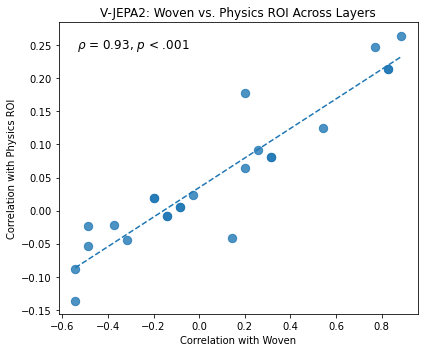

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


[ 0.25714286  0.2        -0.37142857 -0.31428571 -0.31428571 -0.14285714
 -0.31428571 -0.2        -0.31428571 -0.14285714 -0.08571429 -0.08571429]


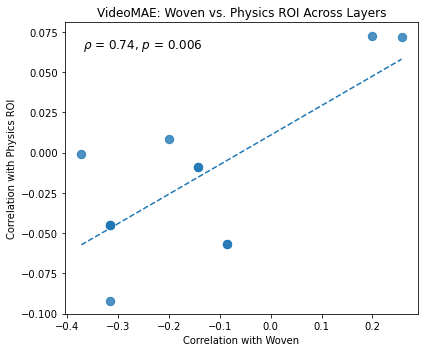

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


[-0.42857143 -0.42857143 -0.31428571 -0.42857143 -0.54285714 -0.37142857
 -0.2         0.14285714 -0.08571429  0.25714286 -0.31428571 -0.48571429]


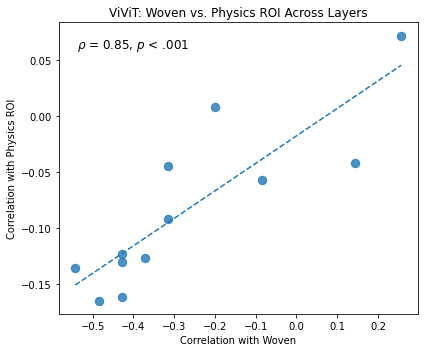

In [8]:
# ============================================================
# Scatter plots:
# Woven correlation vs Physics ROI correlation
# One figure for each video model
# ============================================================

from scipy.stats import spearmanr
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


if not layer_results_df.empty:

    plot_model_order = ["vjepa2", "videomae", "vivit"]

    label_map = {
        "vjepa2": "V-JEPA2",
        "videomae": "VideoMAE",
        "vivit": "ViViT",
    }

    for model_name in plot_model_order:

        # ----------------------------------------------------
        # Get data for this model
        # ----------------------------------------------------
        sub_df = (
            layer_results_df
            .query("model == @model_name")
            .dropna(
                subset=[
                    "woven_spearman",
                    "tower_neural_spearman"
                ]
            )
            .sort_values("layer_number")
            .copy()
        )

        if len(sub_df) == 0:
            continue

        x = sub_df["woven_spearman"].values
        y = sub_df["tower_neural_spearman"].values
        
        print(x)

        # ----------------------------------------------------
        # Spearman correlation across layers
        # ----------------------------------------------------
        rho, p = pearsonr(x, y)

        # ----------------------------------------------------
        # Plot
        # ----------------------------------------------------
        plt.figure(figsize=(6, 5))

        plt.scatter(
            x,
            y,
            s=70,
            alpha=0.8,
        )

        # ----------------------------------------------------
        # Linear best-fit line
        # ----------------------------------------------------
        slope, intercept = np.polyfit(x, y, 1)

        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = slope * x_line + intercept

        plt.plot(
            x_line,
            y_line,
            linestyle="--",
            linewidth=1.5,
        )

        # ----------------------------------------------------
        # Correlation coefficient
        # ----------------------------------------------------
        if p < 0.001:
            corr_text = rf"$\rho$ = {rho:.2f}, $p$ < .001"
        else:
            corr_text = rf"$\rho$ = {rho:.2f}, $p$ = {p:.3f}"

        plt.text(
            0.05,
            0.95,
            corr_text,
            transform=plt.gca().transAxes,
            ha="left",
            va="top",
            fontsize=12,
        )

        # ----------------------------------------------------
        # Labels
        # ----------------------------------------------------
        plt.xlabel("Correlation with Woven")
        plt.ylabel("Correlation with Physics ROI")

        plt.title(
            f"{label_map[model_name]}: "
            "Woven vs. Physics ROI Across Layers"
        )

        plt.tight_layout()

        # ----------------------------------------------------
        # Save
        # ----------------------------------------------------
        plt.savefig(
            f"{model_name}_woven_vs_physics_roi_across_layers.eps",
            format="eps",
            bbox_inches="tight",
        )

        plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript back

Overall Pearson r = 0.908, p = 4.772e-19


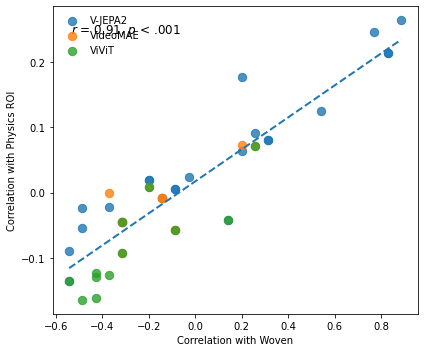

In [12]:
# ============================================================
# Combined scatter plot across all three video models
# One overall correlation / regression line
# ============================================================

plot_model_order = ["vjepa2", "videomae", "vivit"]

label_map = {
    "vjepa2": "V-JEPA2",
    "videomae": "VideoMAE",
    "vivit": "ViViT",
}

combined_df = (
    layer_results_df[
        layer_results_df["model"].isin(plot_model_order)
    ]
    .dropna(
        subset=[
            "woven_spearman",
            "tower_neural_spearman",
        ]
    )
    .copy()
)

x = combined_df["woven_spearman"].values
y = combined_df["tower_neural_spearman"].values


# ------------------------------------------------------------
# Overall Pearson correlation
# ------------------------------------------------------------
r, p = pearsonr(x, y)

print(f"Overall Pearson r = {r:.3f}, p = {p:.4g}")


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))

# Plot points from each model separately
for model_name in plot_model_order:

    sub_df = combined_df.query("model == @model_name")

    plt.scatter(
        sub_df["woven_spearman"],
        sub_df["tower_neural_spearman"],
        s=70,
        alpha=0.8,
        label=label_map[model_name],
    )


# ------------------------------------------------------------
# ONE overall regression line across all models
# ------------------------------------------------------------
slope, intercept = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

plt.plot(
    x_line,
    y_line,
    linestyle="--",
    linewidth=2,
)


# ------------------------------------------------------------
# Overall correlation text
# ------------------------------------------------------------
if p < 0.001:
    corr_text = rf"$r$ = {r:.2f}, $p$ < .001"
else:
    corr_text = rf"$r$ = {r:.2f}, $p$ = {p:.3f}"

plt.text(
    0.05,
    0.95,
    corr_text,
    transform=plt.gca().transAxes,
    ha="left",
    va="top",
    fontsize=12,
)


plt.xlabel("Correlation with Woven")
plt.ylabel("Correlation with Physics ROI")

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    "all_video_models_woven_vs_physics_roi.eps",
    format="eps",
    bbox_inches="tight",
)

plt.show()